In [47]:
import numpy as np 
import matplotlib.pyplot as plt 
import torchvision 
import torchvision.transforms as transforms 
import torch 
import torch.nn as nn 
import torch.optim as optim
from tqdm.auto import tqdm 

CIFAR-10 dataset downloaded and loaded successfully!


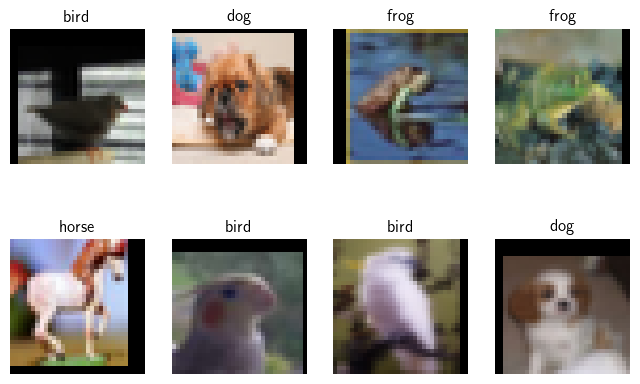

In [50]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

print("CIFAR-10 dataset downloaded and loaded successfully!")

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(8,5))
for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i]
    img = img * 0.5 + 0.5        # unnormalize
    img = img.permute(1, 2, 0)  # C,H,W → H,W,C

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()


In [24]:
class CNNModel(nn.Module): 
    def __init__(self): 
        super().__init__() 

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5) 
        self.fc2 = nn.Linear(512, 10) 


    def forward(self, x): 
        x = torch.relu(self.conv1(x)) 
        x = torch.max_pool2d(x, 2) 
        x = torch.relu(self.conv2(x)) 
        x = torch.max_pool2d(x, 2) 
        x = torch.relu(self.conv3(x)) 
        x = torch.max_pool2d(x, 2) 
        x = x.view(-1, 128 * 4 * 4) 
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 10

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in tqdm(range(num_epochs)):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(trainloader))
    train_accuracies.append(100 * correct_train / total_train)
    
    model.eval()
    running_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    
    test_losses.append(running_loss / len(testloader))
    test_accuracies.append(100 * correct_test / total_test)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, "
          f"Train Accuracy: {train_accuracies[-1]:.2f}%, Test Accuracy: {test_accuracies[-1]:.2f}%")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch [1/10], Train Loss: 1.6118, Test Loss: 1.2964, Train Accuracy: 40.33%, Test Accuracy: 52.99%
Epoch [2/10], Train Loss: 1.2597, Test Loss: 1.1192, Train Accuracy: 54.66%, Test Accuracy: 60.14%
Epoch [3/10], Train Loss: 1.1126, Test Loss: 1.0009, Train Accuracy: 60.41%, Test Accuracy: 64.36%
Epoch [4/10], Train Loss: 1.0244, Test Loss: 0.9600, Train Accuracy: 63.93%, Test Accuracy: 65.91%
Epoch [5/10], Train Loss: 0.9585, Test Loss: 0.8864, Train Accuracy: 66.61%, Test Accuracy: 68.71%
Epoch [6/10], Train Loss: 0.9113, Test Loss: 0.8331, Train Accuracy: 68.16%, Test Accuracy: 71.21%
Epoch [7/10], Train Loss: 0.8701, Test Loss: 0.7970, Train Accuracy: 69.62%, Test Accuracy: 72.03%
Epoch [8/10], Train Loss: 0.8414, Test Loss: 0.8071, Train Accuracy: 70.89%, Test Accuracy: 71.89%
Epoch [9/10], Train Loss: 0.8213, Test Loss: 0.7773, Train Accuracy: 71.57%, Test Accuracy: 73.06%
Epoch [10/10], Train Loss: 0.7973, Test Loss: 0.7738, Train Accuracy: 72.46%, Test Accuracy: 73.14%


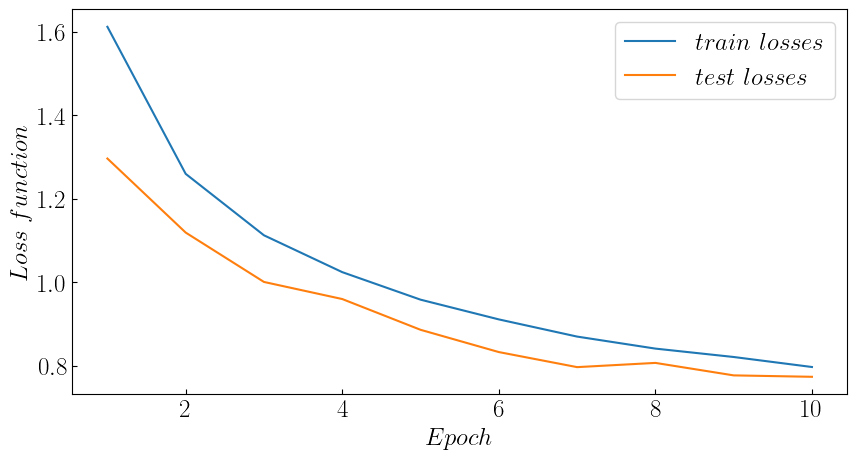

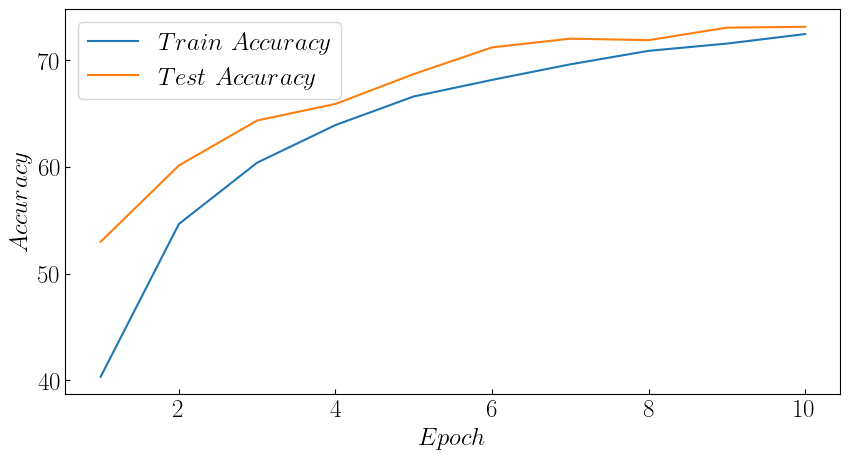

In [25]:
plt.rc('text', usetex = True)
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label = r"$train$ $losses$") 
plt.plot(range(1, num_epochs+1), test_losses, label = r"$test$ $losses$") 
plt.legend(fontsize = 18) 
plt.ylabel(r"$Loss$ $function$", fontsize = 18) 
plt.xlabel(r"$Epoch$", fontsize = 18) 
plt.tick_params(direction = "in", labelsize = 18)


plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_accuracies, label=r'$Train$ $Accuracy$')
plt.plot(range(1, num_epochs+1), test_accuracies, label=r'$Test$ $Accuracy$')
plt.xlabel(r'$Epoch$', fontsize = 18)
plt.ylabel(r'$Accuracy$', fontsize = 18)
plt.tick_params(direction = "in", labelsize = 18)
plt.legend(fontsize = 18)

MNIST Dataset

MNIST dataset loaded!
Train samples: 60000, Test samples: 10000
Visualization...


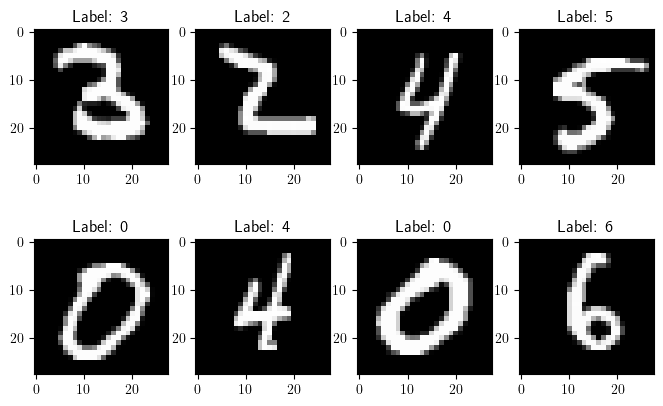

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 0.2637, Test Loss: 0.0521 | Train Acc: 91.83%, Test Acc: 98.19%
Epoch 2/15 | Train Loss: 0.0966, Test Loss: 0.0366 | Train Acc: 97.09%, Test Acc: 98.80%
Epoch 3/15 | Train Loss: 0.0733, Test Loss: 0.0336 | Train Acc: 97.83%, Test Acc: 98.92%
Epoch 4/15 | Train Loss: 0.0617, Test Loss: 0.0278 | Train Acc: 98.21%, Test Acc: 99.12%
Epoch 5/15 | Train Loss: 0.0512, Test Loss: 0.0298 | Train Acc: 98.45%, Test Acc: 99.11%
Epoch 6/15 | Train Loss: 0.0443, Test Loss: 0.0250 | Train Acc: 98.65%, Test Acc: 99.27%
Epoch 7/15 | Train Loss: 0.0390, Test Loss: 0.0229 | Train Acc: 98.81%, Test Acc: 99.33%
Epoch 8/15 | Train Loss: 0.0346, Test Loss: 0.0254 | Train Acc: 98.92%, Test Acc: 99.29%
Epoch 9/15 | Train Loss: 0.0335, Test Loss: 0.0272 | Train Acc: 98.95%, Test Acc: 99.23%
Epoch 10/15 | Train Loss: 0.0294, Test Loss: 0.0231 | Train Acc: 99.06%, Test Acc: 99.28%
Epoch 11/15 | Train Loss: 0.0275, Test Loss: 0.0233 | Train Acc: 99.10%, Test Acc: 99.29%
Epoch 12/15 | Train

In [60]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torchvision 
from torch.utils.data import DataLoader 

transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.5,), (0.5,))]) 

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = DataLoader(testset, batch_size=64, shuffle=False)

print("MNIST dataset loaded!")
print("=====================================================")


print(f"Train samples: {len(trainset)}, Test samples: {len(testset)}")

print("Visualization...") 

dataiter = iter(trainloader) 
images, labels = next(dataiter) 

plt.figure(figsize=(8, 5)) 
for i in range(8): 
    plt.subplot(2, 4, i+1) 
    plt.imshow(images[i].squeeze(), cmap = 'gray') 
    plt.title(f"Label: {labels[i].item()}")
plt.show() 

class MNIST_CNN(nn.Module): 
    def __init__(self): 
        super().__init__() 
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1) 
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) 
        self.pool = nn.MaxPool2d(2, 2) 

        self.fc1 = nn.Linear(64*7*7, 128) 
        self.dropout = nn.Dropout(0.5) 
        self.fc2 = nn.Linear(128, 10) 

    def forward(self, x): 
        x = torch.relu(self.conv1(x)) 
        x = self.pool(x) 
        x = torch.relu(self.conv2(x)) 
        x = self.pool(x) 
        x = x.view(-1, 64*7*7) 
        x = torch.relu(self.fc1(x)) 
        x = self.dropout(x) 
        x = self.fc2(x) 

        return x 
    
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu') 
model = MNIST_CNN().to(device) 
model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epoch = 15 
train_losses, test_losses = [], [] 
train_acc, test_acc = [], [] 

for epoch in tqdm(range(num_epoch)): 
    model.train() 
    running_loss = 0 
    correct_train = 0 
    total_train = 0 
    for images, labels in trainloader: 
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad() 
        outputs = model(images) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 


        running_loss += loss.item() 
        _, preds = torch.max(outputs, 1) 
        total_train += labels.size(0) 
        correct_train += (preds == labels).sum().item() 

    train_losses.append(running_loss / len(trainloader))
    train_acc.append(100 * correct_train / total_train) 

    model.eval()
    running_loss_test = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss_test += loss.item()
            _, preds = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (preds == labels).sum().item()
    
    test_losses.append(running_loss_test / len(testloader))
    test_acc.append(100 * correct_test / total_test)
    
    print(f"Epoch {epoch+1}/{num_epoch} | "
          f"Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f} | "
          f"Train Acc: {train_acc[-1]:.2f}%, Test Acc: {test_acc[-1]:.2f}%")



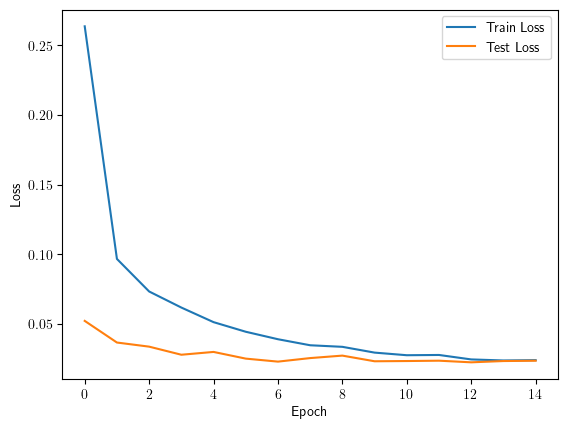

In [61]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


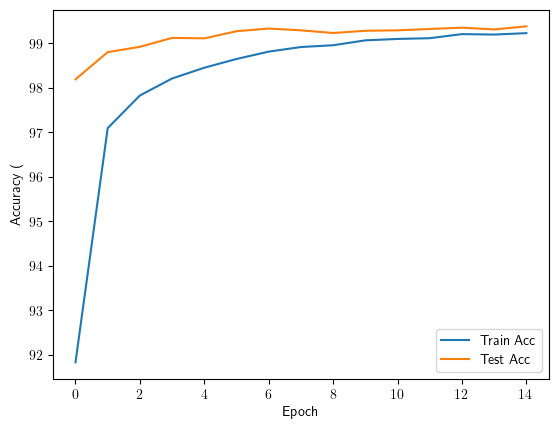

In [62]:
plt.plot(train_acc, label='Train Acc')
plt.plot(test_acc, label='Test Acc')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()


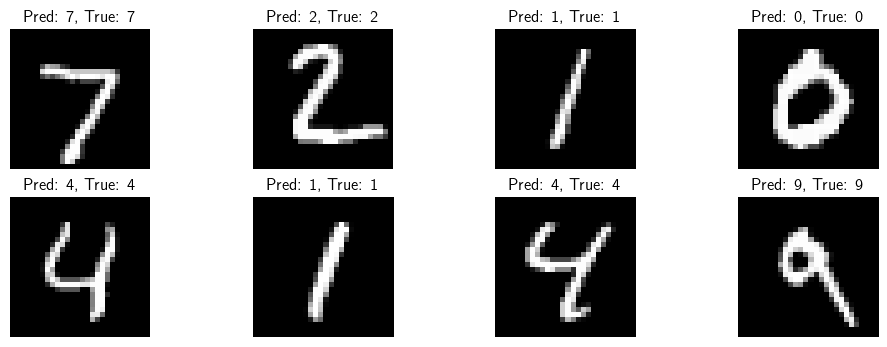

In [63]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}, True: {labels[i].item()}")
    plt.axis('off')
plt.show()


$Aerial$ $Target$ $Detection$ $\&$ $Tracking$

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 1.6762
Epoch 2/10 | Loss: 1.3395
Epoch 3/10 | Loss: 1.1704
Epoch 4/10 | Loss: 1.0513
Epoch 5/10 | Loss: 0.9740
Epoch 6/10 | Loss: 0.9222
Epoch 7/10 | Loss: 0.8744
Epoch 8/10 | Loss: 0.8341
Epoch 9/10 | Loss: 0.8122
Epoch 10/10 | Loss: 0.7819
Precision: 0.744
Recall: 0.738


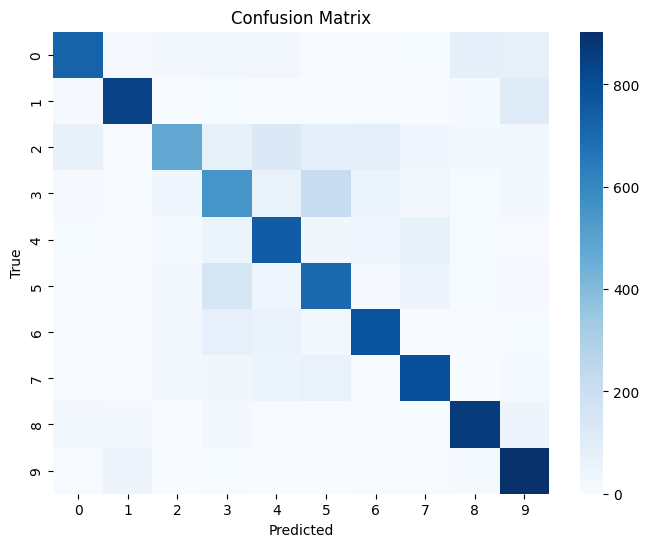

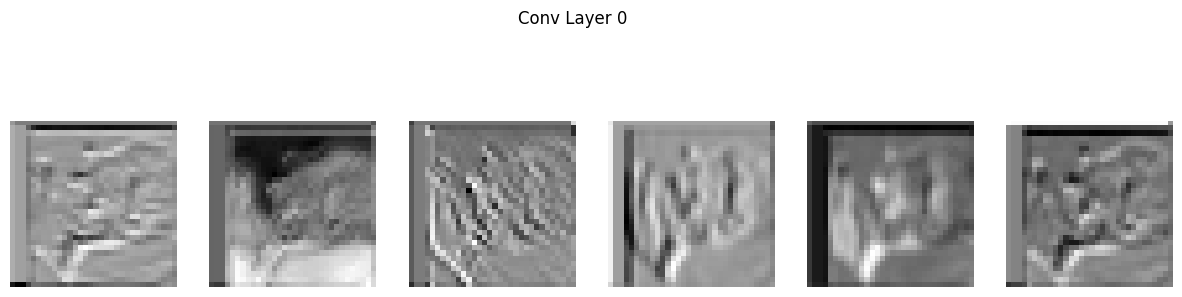

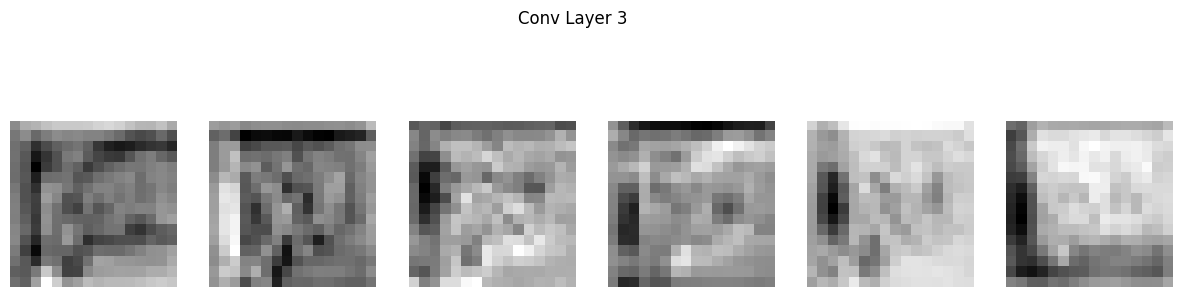

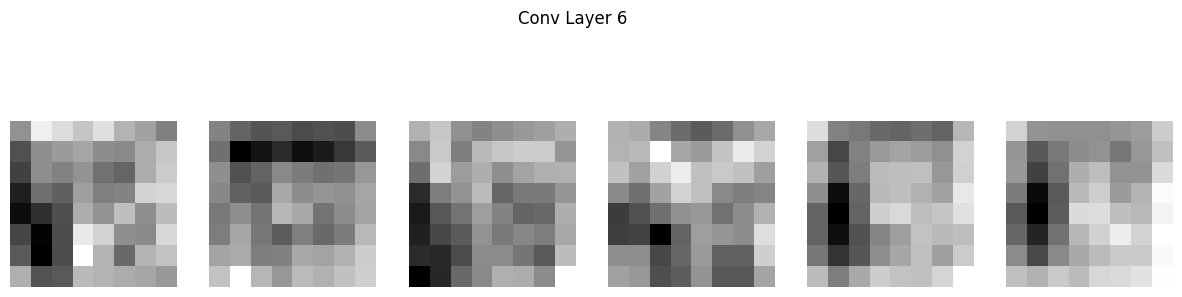

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
from tqdm.auto import tqdm


transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes


class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.4f}")


model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

def visualize_feature_maps(model, image, print_stats=True):
    """
    Visualize feature maps for each Conv layer in the model
    image: a single image tensor (C,H,W)
    print_stats: if True, print stats of feature maps for analysis
    """
    model.eval()
    image = image.unsqueeze(0).to(device)  # add batch dimension
    x = image

    for i, layer in enumerate(model.features):
        x = layer(x)

        if isinstance(layer, nn.Conv2d):
            feature_maps = x.squeeze(0).cpu().detach()  # (C,H,W)
            num_maps = min(6, feature_maps.shape[0])

            # --- Visualization ---
            fig, axes = plt.subplots(1, num_maps, figsize=(15,4))
            fig.suptitle(f"Conv Layer {i} Feature Maps")
            for j in range(num_maps):
                axes[j].imshow(feature_maps[j].numpy(), cmap='gray')
                axes[j].axis('off')
            plt.show()

            # --- Analysis / Print stats ---
            if print_stats:
                print(f"Layer {i} -> Shape: {feature_maps.shape}")
                means = feature_maps.view(feature_maps.shape[0], -1).mean(dim=1)
                maxs  = feature_maps.view(feature_maps.shape[0], -1).max(dim=1).values
                print("Mean activation per channel:", means[:6].numpy())
                print("Max activation per channel: ", maxs[:6].numpy())
                print("-"*50)

# Sample image
sample_img, _ = testset[0]
visualize_feature_maps(model, sample_img)
